In [1]:
# Cell 1: Setup & Imports
import sys
sys.path.insert(0, '../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython import get_ipython

from src.utils.config import get_config
from src.utils.db import get_db

# Configure plotting
plt.style.use('dark_background')
sns.set_palette("husl")
get_ipython().run_line_magic('matplotlib', 'inline')

# Initialize connections
config = get_config()
db = get_db()

print(f"Environment: {config.environment}")
print(f"Database: Connected")

2026-05-17 18:19:54 [info     ] database_initialized           database=postgres host=aws-0-eu-west-1.pooler.supabase.com pool_size=10 ssl_mode=require
Environment: Environment.DEVELOPMENT
Database: Connected


In [2]:
# Cell 2: Data Overview
races = db.execute_dataframe("SELECT * FROM races ORDER BY year, round")
drivers = db.execute_dataframe("SELECT * FROM drivers")
constructors = db.execute_dataframe("SELECT * FROM constructors")
results = db.execute_dataframe("SELECT * FROM results")

print(f"Races: {len(races):,}")
print(f"Drivers: {len(drivers):,}")
print(f"Constructors: {len(constructors):,}")
print(f"Results: {len(results):,}")

2026-05-17 18:20:03 [debug    ] sql_query_executing            parameters={} statement='SELECT * FROM races ORDER BY year, round'
2026-05-17 18:20:04 [debug    ] database_transaction_committed
2026-05-17 18:20:04 [debug    ] sql_query_executing            parameters={} statement='SELECT * FROM drivers'
2026-05-17 18:20:05 [debug    ] database_transaction_committed
2026-05-17 18:20:06 [debug    ] sql_query_executing            parameters={} statement='SELECT * FROM constructors'
2026-05-17 18:20:06 [debug    ] database_transaction_committed
2026-05-17 18:20:07 [debug    ] sql_query_executing            parameters={} statement='SELECT * FROM results'
2026-05-17 18:20:11 [debug    ] database_transaction_committed
Races: 131
Drivers: 54
Constructors: 14
Results: 2,618


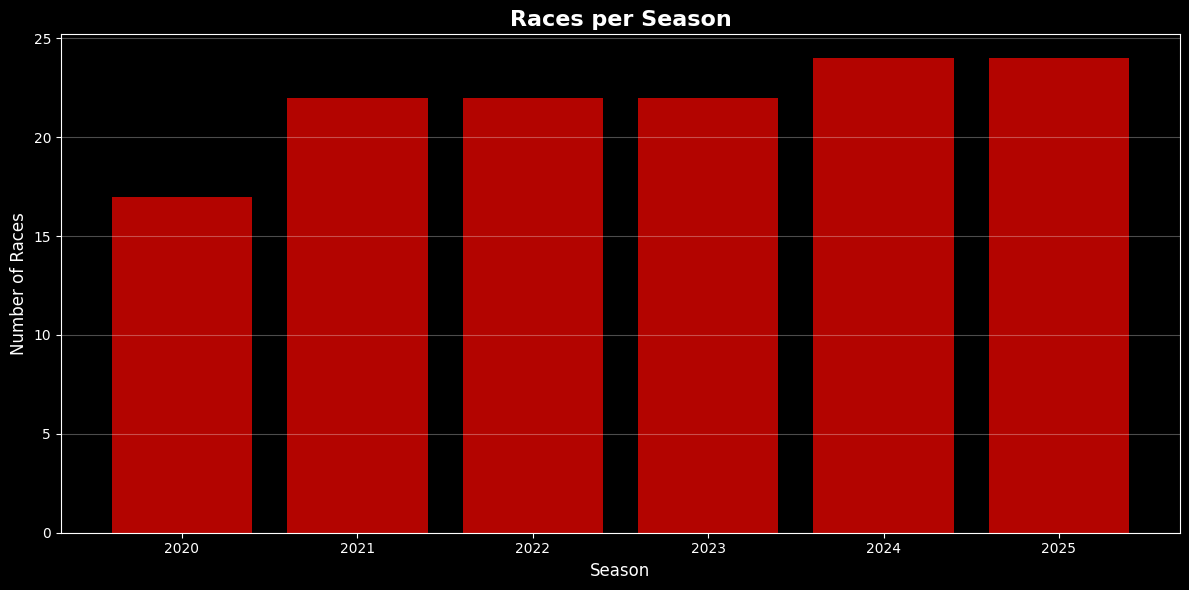

In [3]:

# Cell 3: Season Distribution
season_counts = races.groupby('year').size().reset_index(name='race_count')

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(season_counts['year'], season_counts['race_count'], color='#e10600', alpha=0.8)
ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Number of Races', fontsize=12)
ax.set_title('Races per Season', fontsize=16, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


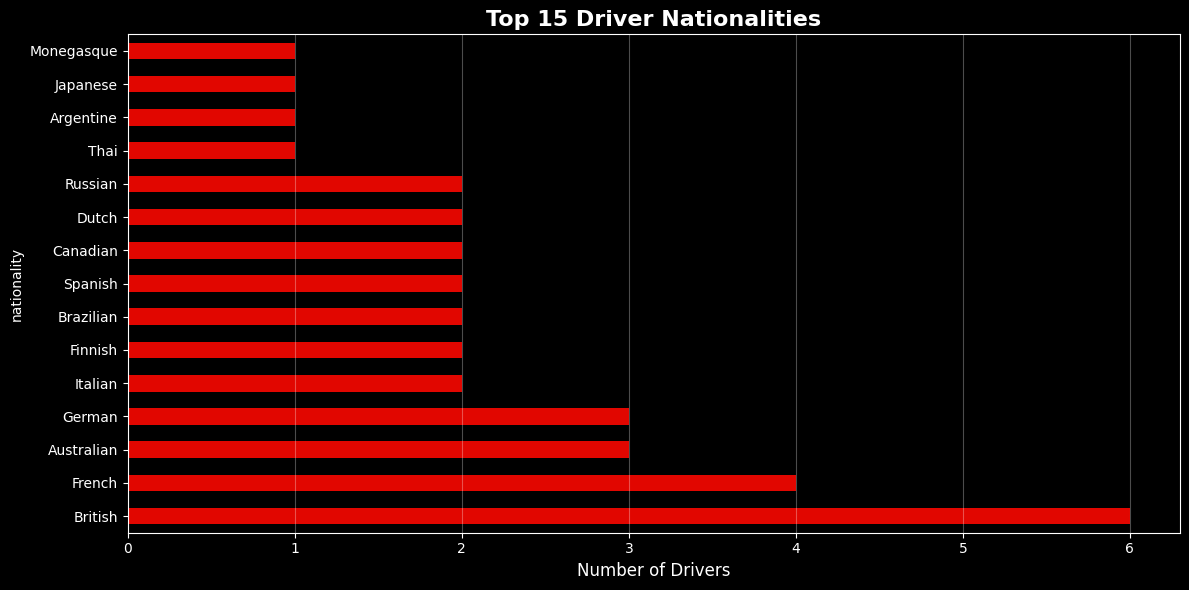

In [4]:

# Cell 4: Driver Nationality Distribution
nationality_counts = drivers['nationality'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
nationality_counts.plot(kind='barh', ax=ax, color='#e10600')
ax.set_xlabel('Number of Drivers', fontsize=12)
ax.set_title('Top 15 Driver Nationalities', fontsize=16, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

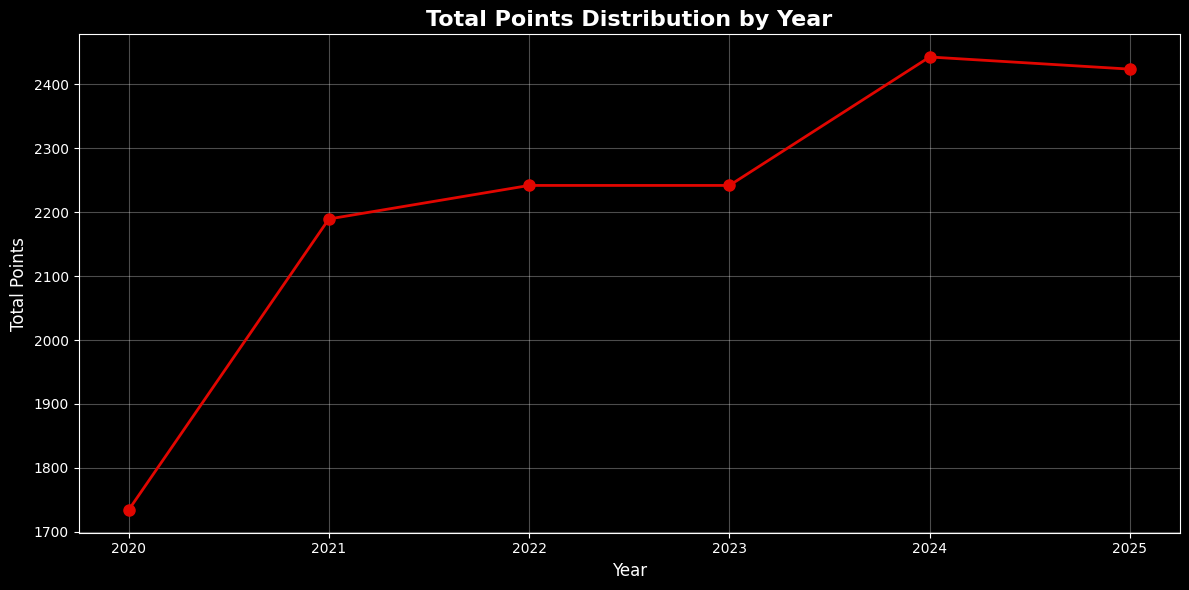


Points by Year:
   year  points
0  2020  1734.0
1  2021  2189.5
2  2022  2242.0
3  2023  2242.0
4  2024  2443.0
5  2025  2424.0


In [5]:
# Cell 5: Points Distribution Analysis - FIXED
# First, join results with races to get the year
import pandas as pd
from sqlalchemy import create_engine, text
from src.utils.config import get_config

# Get database connection
config = get_config()
engine = create_engine(config.database.connection_string)

# Query with join to get year
query = """
SELECT 
    r.year,
    res.points,
    res.position,
    d.forename,
    d.surname,
    c.name as constructor
FROM results res
JOIN races r ON res.race_id = r.race_id
JOIN drivers d ON res.driver_id = d.driver_id
JOIN constructors c ON res.constructor_id = c.constructor_id
"""

results_with_year = pd.read_sql(query, engine)

#group by year
points_dist = results_with_year.groupby('year')['points'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(points_dist['year'], points_dist['points'], marker='o', linewidth=2, markersize=8, color='#e10600')
ax.set_title('Total Points Distribution by Year', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Total Points', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nPoints by Year:")
print(points_dist)

2026-05-17 18:20:49 [debug    ] sql_query_executing            parameters={} statement='SELECT * FROM circuits'
2026-05-17 18:20:50 [debug    ] database_transaction_committed


C:\Users\user\AppData\Local\Temp\ipykernel_8704\2223901361.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  c=circuits['altitude'].fillna(0),


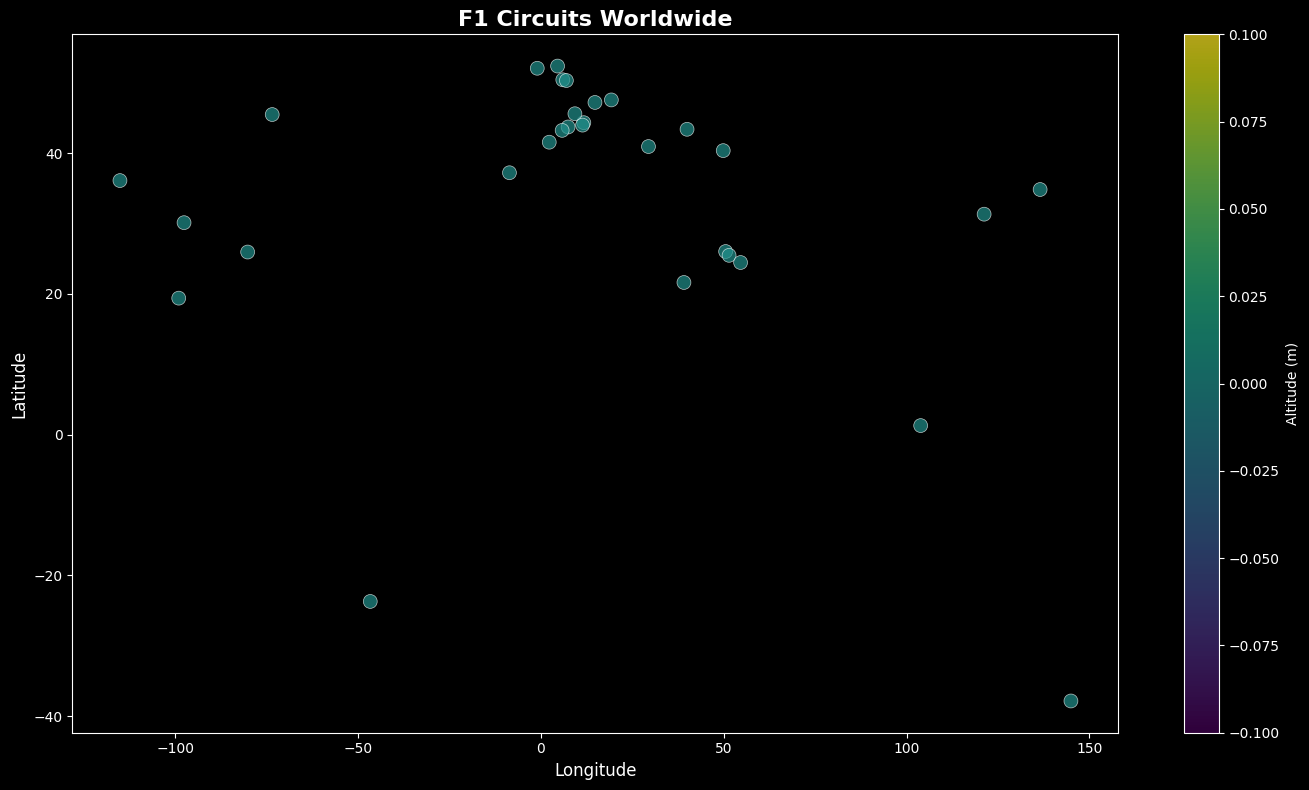

In [6]:
# Cell 6: Circuit Geography
circuits = db.execute_dataframe("SELECT * FROM circuits")

fig, ax = plt.subplots(figsize=(14, 8))
scatter = ax.scatter(
    circuits['longitude'], 
    circuits['latitude'],
    s=100,
    c=circuits['altitude'].fillna(0),
    cmap='viridis',
    alpha=0.7,
    edgecolors='white',
    linewidth=0.5
)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('F1 Circuits Worldwide', fontsize=16, fontweight='bold')
plt.colorbar(scatter, label='Altitude (m)')
plt.tight_layout()
plt.show()